# This notebook walks through recording extracellular voltage using the simulator 

In [1]:
# Imports and loading of NEURON dll
import numpy as np
from neuron import h
import simulation as sim
import matplotlib.pyplot as plt
import extracellular as ex
import helperFuncs as hf

## Step 1: Setup simualted cell

### Hard reset to delete any lingering segments 

In [2]:
# clear all NEURON sims. Required if you are going to be running many exps
#  in Jupyter notebooks.
for sec in h.allsec():
   h.delete_section(sec=sec)

### Build a cell, point to the params file of interest 

In [3]:
# Code to setup a single simulated RGC
# Default params file located at: 'cell_param_files/params_35.csv'
RGC = sim.Local_Cell()
filename = 'cell_param_files/params_35_v2.csv'
RGC.build_cell(filename,'mammalian_spike_35')

After any change to cell geometry or nseg, be sure to invoke setpointers()


### Output simple facts: (x,y,z) of soma center and all compartments 

In [4]:
# print out where the center of the soma is located and shift if needed
#  Note, behind the scenes this is shifting all simualted compartments by 
#  the necessary x,y,z transforms to get the cell to the right spot 
print('Current soma center is located at: ', RGC.soma_center) # units: [um]

# x_shift = -1000 + 997.8304687738416
# RGC.shift_cell_x_y_z(0+x_shift,0,0)

# convert degrees to radians
#  by default the axon points towards -x, so a 90 degree rotation would make it 
#  point in the -y direction 
# degrees = 70
# radians = np.deg2rad(degrees)

# RGC._rotateZ(radians)
# print('New soma center is located at: ', RGC.soma_center)

# RGC.shift_cell_x_y_z(80,-20,0)
# print('New soma center is located at: ', RGC.soma_center)

Current soma center is located at:  [-11.9399995803833, 0.0, 10.0]


In [5]:
# Code to traverse through all sections and segments of a cell. This is very
#  useful for debugging and probing different features (membrane voltage, 
#  currents, channel dynamics) at each segment. It also helps to understand 
#  how the cell is layed out in space. 
for sec in RGC.section_list: 
    for seg in sec:
        print(seg)
        print('Segment coordinates: ', seg.x_xtra, seg.y_xtra, seg.z_xtra)

Cell[0].soma(0.1)
Segment coordinates:  -11.9399995803833 0.0 2.0
Cell[0].soma(0.3)
Segment coordinates:  -11.9399995803833 0.0 6.000000000000001
Cell[0].soma(0.5)
Segment coordinates:  -11.9399995803833 0.0 10.000000000000004
Cell[0].soma(0.7)
Segment coordinates:  -11.9399995803833 0.0 14.000000000000002
Cell[0].soma(0.9)
Segment coordinates:  -11.9399995803833 0.0 18.0
Cell[0].dend[0](0.125)
Segment coordinates:  -3.6953151163387163 4.343730210962006 5.03043851707471
Cell[0].dend[0](0.375)
Segment coordinates:  -5.685945253648718 8.93119072825345 -0.9086844487758685
Cell[0].dend[0](0.625)
Segment coordinates:  -7.81054909424161 13.615720950482658 -6.601027863452128
Cell[0].dend[0](0.875)
Segment coordinates:  -12.301887902331721 19.384626347634363 -7.394698611811695
Cell[0].dend[50](0.5)
Segment coordinates:  -16.884999752044678 19.614999771118164 -7.5
Cell[0].dend[52](0.25)
Segment coordinates:  -20.19049221075576 16.439785067507984 -7.500000000000001
Cell[0].dend[52](0.75)
Segment

## Step 2: Setup electrical stimulus 

In [6]:
### Most features of the stimulus are set up a struct (dict) called Stim 
Stim = {}

# temporal features of the sitmulus 
Stim['pulseShape'] = 'triphasic'
Stim['dt'] = .005 # units: [ms]
Stim['delay'] = 10 # units: [ms]
Stim['dur'] = 0.05 # units: [ms]
Stim['stop'] = 80 # units: [ms]
Stim['amp'] = 2.5 # units: [uA]

# calibration phase of the stimulus 
Stim['initDur'] = 50 # units: [ms]
Stim['initDt'] = 1 # units: [ms]
Stim['vInit'] = -70 # units: [mV] #TODO: Old is -70

# spatial features of the stimulus 
# --> specifically defining the electrode geometry 
Stim['electrodes'] = [[-10,0,40]] # units: [um] 
Stim['electrode_type'] = 'disk'
Stim['rhoExt'] = 1000 # Ohm*cm
Stim['elecDiam'] = 15 # um
Stim['polarity'] = -1 # anodic == 1; cathodic == -1 

Stim['pulseRatioTri'] = [-2/3,1,-1/3]
Stim['pulseRatioBi'] = [1,-1]
Stim['frequency'] = 10 # units: [Hz]

## Step 3: Set up recording vectors in order to probe what happened 

### Current recording vectors at all segment compartments

In [7]:
# Setup dictionary to capture iOut at all cell compartments
iOut = {}
h.cvode.use_fast_imem(True) # needed for i_membrane_ / extracellular recording
for section in RGC.section_list:
    iOut[section.name()] = {}
    for seg, i in zip(section,range(section.nseg)):
        iOut[section.name()]['imem' + str(i)] = h.Vector().record(seg._ref_i_membrane_)

### Voltage recording vectors at all segment compartments 

In [30]:
vOut = {}
for section in RGC.section_list:
    vOut[section.name()] = {}
    for seg, i in zip(section,range(section.nseg)):
        vOut[section.name()]['vmem' + str(i)] = h.Vector().record(seg._ref_v)

### Time vector

In [31]:
# set up recoring vector for time in the simulation 
t = h.Vector().record(h._ref_t)

## Step 4: Apply stimulus to the cell! (Run only one cell below)

In [32]:
# First, decide if you want current clamp (visually-) or electrode 
#   current (extracellularly-) evoked spiking
stim_type = 'clamp' # 'clamp' or 'extra'

In [33]:
if stim_type == 'clamp':
    # Current clamp simulation
    h.init()
    h.v_init = -64 # Old = -70
    h.finitialize(h.v_init)
    h.fcurrent()
    h.dt = 0.001
    h.tstop = 25

    # # Create intracellular stimulus
    # CurrentClamp = h.IClamp(0.5,sec=RGC.cell.soma) # inject current to soma
    # # CurrentClamp = h.IClamp(1,sec=h.axon) # inject current to axon
    # CurrentClamp.delay= 1 # msec
    # CurrentClamp.dur= 0.15 # msec
    # CurrentClamp.amp= 3.9 # nA

    # Create intracellular stimulus
    CurrentClamp = h.IClamp(0.5,sec=RGC.cell.dend[0]) # inject current to soma
    # CurrentClamp = h.IClamp(1,sec=h.axon) # inject current to axon
    CurrentClamp.delay= 1 # msec
    CurrentClamp.dur= 0.15 # msec
    CurrentClamp.amp= 2.9 # nA

    # run sim!
    h.run()
elif stim_type == 'extra':
    # Need to do this everytime the stimulus parameters are changed
    hf.setupTransferImpedance(Stim, RGC)

    # Play the stimulus into the cell, setting it up for stimulation
    Stim['amp'] = Stim['polarity']*Stim['amp']
    tsvec, isvec = hf.setupStimulus(Stim)
    isvec.play(h._ref_is_xtra, tsvec, 1) 

    # Initialization phase of the simulation 
    h.init()
    h.tstop = Stim['initDur']
    h.dt = Stim['initDt']
    h.finitialize(Stim['vInit'])
    h.continuerun(h.tstop)

    # Run the simulation 
    h.tstop = Stim['initDur'] + Stim['stop']
    h.steps_per_ms = int(1/Stim['dt'])
    h.dt = Stim['dt']
    h.continuerun(h.tstop)
    print('***** sim done *****')

## Step 5: Visualize what happened

### Extracellular recording as observed from a given recording electrode (point source approx)

In [34]:
# Recording electrode position (default is the stimulating electrode)
# recElec = Stim['electrodes'][0]
recElec = [-600,0,35]

# setup vector where to store extracellular voltage profile
if stim_type == 'clamp':
    timeStepsRec = int(h.tstop/h.dt)+1
    dtFac = 1
    recOut = np.zeros((timeStepsRec))
elif stim_type == 'extra':
    timeStepsRec = int(Stim['stop']/Stim['dt'])+1
    dtFac = 1
    recOut = np.zeros((timeStepsRec))


# Setup transfer impedance between recording electrode and cell, then 
#  scale recorded membrane currents to get extracellular voltage profile 
for section in RGC.section_list:
    # print(section.name())
    # Loop over all segments in section
    for seg, k in zip(section,range(section.nseg)):
        # Compute distance from electrode to center of each segment [um]
        dist = np.sqrt((seg.xtra.x-recElec[0])**2 + (seg.xtra.y-recElec[1])**2 \
                       + (seg.xtra.z-recElec[2])**2)
        
        # Set transfer impedance for each segment [MOhm]
        tf = Stim['rhoExt'] / (4.0*np.pi*dist*(1e-4)) * 1e-6

        # recOut units: 1e3*MOhm*nA == uV
        if stim_type == 'clamp':
            recOut += 1e3 * tf * \
                (iOut[section.name()]['imem' + str(k)].as_numpy())
        elif stim_type == 'extra':
            recOut += 1e3 * tf * \
                (iOut[section.name()]['imem' + str(k)].as_numpy()[int(Stim['initDur']/Stim['initDt'])::dtFac])

Text(0, 0.5, 'Extracellular voltage [uV]')

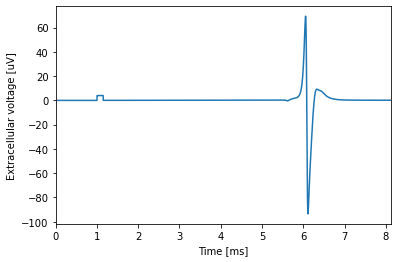

In [35]:
# Plot extracellular voltaged recorded on recElec
if stim_type == 'clamp':
    plt.plot(np.arange(0,h.tstop+h.dt,h.dt),recOut)
    # do some adaptive peak finding to zoom in on spike
    peak_time = t[recOut.argmin()]
    plt.xlim(0,peak_time+2)
elif stim_type == 'extra':
    plt.plot(np.arange(0,Stim['stop']+Stim['dt'],Stim['dt']),recOut)
    plt.xlim(9.5,15)

plt.xlabel('Time [ms]')
plt.ylabel('Extracellular voltage [uV]')

### Now try with disk electrode approximations

In [36]:
# Recording electrode position (default is the stimulating electrode)
# recElec = Stim['electrodes'][0]
recElec = [-200,0,45]

# setup vector where to store extracellular voltage profile
if stim_type == 'clamp':
    timeStepsRec = int(h.tstop/h.dt)+1
    dtFac = 1
    recOut = np.zeros((timeStepsRec))
elif stim_type == 'extra':
    timeStepsRec = int(Stim['stop']/Stim['dt'])+1
    dtFac = 1
    recOut = np.zeros((timeStepsRec))

print(recOut)


# Setup transfer impedance between recording electrode and cell, then 
#  scale recorded membrane currents to get extracellular voltage profile 
for section in RGC.section_list:
    # print(section.name())
    # Loop over all segments in section
    for seg, k in zip(section,range(section.nseg)):
        # Distance from electrode to center of each segment [cm]
        r = 1e-4*\
            np.sqrt((seg.xtra.x - (recElec[0]))**2\
                    + (seg.xtra.y - (recElec[1]))**2)
        # Vertical distance [cm]
        z = 1e-4*(seg.xtra.z-recElec[2])

        # Transfer impedance [MOhm]  
        rDisk = 1e-4*Stim['elecDiam']/2             
        tf = 1e-6*(2.0*Stim['rhoExt'])/(4.0*np.pi*rDisk) \
            * np.arcsin((2*rDisk) / \
            (np.sqrt((r-rDisk)**2+z**2)+np.sqrt((r+rDisk)**2+z**2)))
                    
        # recOut units: 1e3*MOhm*nA == uV
        if stim_type == 'clamp':
            recOut += 1e3 * tf * \
                (iOut[section.name()]['imem' + str(k)].as_numpy())
        elif stim_type == 'extra':
            recOut += 1e3 * tf * \
                (iOut[section.name()]['imem' + str(k)].as_numpy()[int(Stim['initDur']/Stim['initDt'])::dtFac])

[0. 0. 0. ... 0. 0. 0.]


Text(0, 0.5, 'Extracellular voltage [uV]')

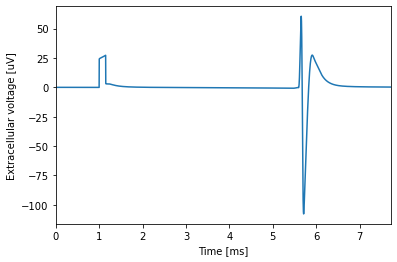

In [37]:
# Plot extracellular voltaged recorded on recElec
if stim_type == 'clamp':
    plt.plot(np.arange(0,h.tstop+h.dt,h.dt),recOut)
    # do some adaptive peak finding to zoom in on spike
    peak_time = t[recOut.argmin()]
    plt.xlim(0,peak_time+2)
elif stim_type == 'extra':
    plt.plot(np.arange(0,Stim['stop']+Stim['dt'],Stim['dt']),recOut)
    plt.xlim(9.5,15)

plt.xlabel('Time [ms]')
plt.ylabel('Extracellular voltage [uV]')

## Extra: If you don't know the current threshold for this electrode, run this block 

In [17]:
# # TODO: Make sure Stim is defined with everything you want (other than amp as that is what this is finding)
# hf.setupTransferImpedance(Stim, RGC)
# thr_c, t_vec, vRec_cathodic = hf.lowerThreshold(Stim, RGC, lower=0, upper=5, num=25, epsilon=0.02)

In [38]:
## Function to return extracellular voltage at recElec
def extracellular_voltage(Stim,RGC,iOut,recElec,stim_type='clamp'):
    # setup vector where to store extracellular voltage profile
    if stim_type == 'clamp':
        timeStepsRec = int(h.tstop/h.dt)+1
        dtFac = 1
        recOut = np.zeros((timeStepsRec))
    elif stim_type == 'extra':
        timeStepsRec = int(Stim['stop']/Stim['dt'])+1
        dtFac = 1
        recOut = np.zeros((timeStepsRec))


    # Setup transfer impedance between recording electrode and cell, then 
    #  scale recorded membrane currents to get extracellular voltage profile 
    for section in RGC.section_list:
        # print(section.name())
        # Loop over all segments in section
        for seg, k in zip(section,range(section.nseg)):
            # Distance from electrode to center of each segment [cm]
            r = 1e-4*\
                np.sqrt((seg.xtra.x - (recElec[0]))**2\
                        + (seg.xtra.y - (recElec[1]))**2)
            # Vertical distance [cm]
            z = 1e-4*(seg.xtra.z-recElec[2])

            # Transfer impedance [MOhm]  
            rDisk = 1e-4*Stim['elecDiam']/2             
            tf = 1e-6*(2.0*Stim['rhoExt'])/(4.0*np.pi*rDisk) \
                * np.arcsin((2*rDisk) / \
                (np.sqrt((r-rDisk)**2+z**2)+np.sqrt((r+rDisk)**2+z**2)))
                        
            # recOut units: 1e3*MOhm*nA == uV
            if stim_type == 'clamp':
                recOut += 1e3 * tf * \
                    (iOut[section.name()]['imem' + str(k)].as_numpy())
            elif stim_type == 'extra':
                recOut += 1e3 * tf * \
                    (iOut[section.name()]['imem' + str(k)].as_numpy()[int(Stim['initDur']/Stim['initDt'])::dtFac])
                
    return recOut # units: [uV]

## Plot the EI for the entire electrode array

In [2]:
# import electrode array (30um)
electrodes = hf.generate_electrode_map(519)

In [3]:
for elec in electrodes:
    if elec[1] == 0:
        print(elec)

[120.   0.]
[240.   0.]
[360.   0.]
[300.   0.]
[180.   0.]
[60.  0.]
[-60.   0.]
[-180.    0.]
[-300.    0.]
[-360.    0.]
[-240.    0.]
[-120.    0.]
[0. 0.]


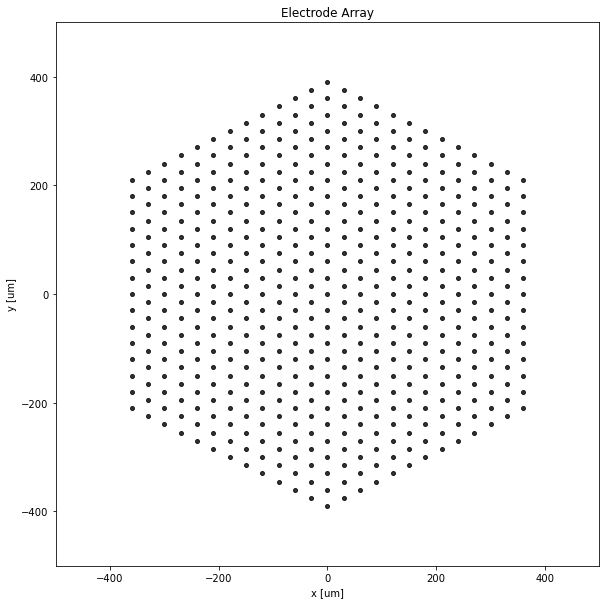

In [4]:
# Plot the simulated cell on the electrode array 
# plot electrode array using plt
fig = plt.figure(figsize=(10,10))
ax = fig.add_subplot(111)
                    
for ii,elec in enumerate(electrodes):
    ax.plot(elec[0],elec[1],'o',color='black',markersize=4,alpha=0.8)

# for sec in RGC.section_list:
#     for seg in sec:
#         ax.plot(seg.x_xtra,seg.y_xtra,'o',color='red',markersize=1)

ax.set_aspect('equal')
plt.xlim([-500,500])
plt.ylim([-500,500])
plt.xlabel('x [um]')
plt.ylabel('y [um]')
plt.title('Electrode Array')
plt.show()

In [42]:
dend_compartments = []
# Save dendritic X,Y coordinate 
for sec in RGC.section_list:
    # if sec.name() contains 'dend'
    if 'dend' in sec.name():
        dend_x = []
        dend_y = []
        for seg in sec:
            dend_x.append(seg.x_xtra)
            dend_y.append(seg.y_xtra)
        dend_compartments.append([dend_x,dend_y])

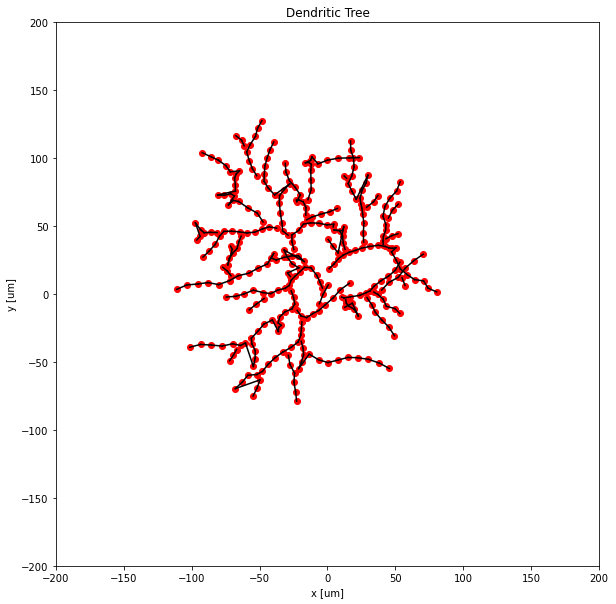

In [43]:
# Plot dend_x, dend_y and connect nearest scatter points with a line
fig = plt.figure(figsize=(10,10))
ax = fig.add_subplot(111)
last_coord = []
notFirst = False
for dend_x,dend_y in dend_compartments:
    ax.scatter(dend_x,dend_y,color='red')
    if notFirst:
        # If distance between last_coord[-1] and dend_x[0] is less than 20, connect them
        if np.sqrt((last_coord[-1][0]-dend_x[0])**2 + (last_coord[-1][1]-dend_y[0])**2) < 20:
            ax.plot([last_coord[-1][0],dend_x[0]],[last_coord[-1][1],dend_y[0]],color='black')
    for i in range(len(dend_x)-1):
        ax.plot([dend_x[i],dend_x[i+1]],[dend_y[i],dend_y[i+1]],color='black')
    # Save last coord
    last_coord.append([dend_x[-1],dend_y[-1]])
    notFirst = True

ax.set_aspect('equal')
plt.xlim([-200,200])
plt.ylim([-200,200])
plt.xlabel('x [um]')
plt.ylabel('y [um]')
plt.title('Dendritic Tree')
plt.show()

In [44]:
# # Save dend_compartments to a pickle file
# import pickle
# with open('dend_compartments.pkl','wb') as f:
#     pickle.dump(dend_compartments,f)

In [45]:
# Get extracellular voltage profile for each electrode
# z = 48+15
z = 48
ei_sim = []
for elec in electrodes:
    recElec = [elec[0],elec[1],z]
    recOut = extracellular_voltage(Stim,RGC,iOut,recElec)
    ei_sim.append(recOut)

In [46]:
ei_min_sim = -1*np.min(ei_sim,axis=1)
np.max(ei_min_sim)

868.9359709620301

In [47]:
import visionloader as vl

datapath = '/Volumes/Analysis/2020-10-06-7/kilosort_data000/data000'
datarun = 'data000'
vcd = vl.load_vision_data(datapath,datarun,
                          include_neurons=True,
                          include_ei=True,
                          include_params=True,
                          include_noise=True)

# datapath = '/Volumes/Analysis/2020-10-18-5/kilosort_data002/data002'
# datarun = 'data002'
# vcd = vl.load_vision_data(datapath,datarun,
#                           include_neurons=True,
#                           include_ei=True,
#                           include_params=True,
#                           include_noise=True)

In [48]:
print(vcd.get_all_cells_similar_to_type("parasol"))

[336, 504, 507, 509, 351, 220, 535, 242, 244, 395, 78, 81, 399, 84, 608, 259, 419, 621, 623, 626, 426, 275, 282, 283, 439, 442, 166, 444, 171, 447, 292, 296, 301, 302, 458, 311, 487, 490]


In [49]:
# ei_real = vcd.get_ei_for_cell(164).ei
# print(ei_real.shape)

# # collapse ei into just minimum for every row, call it ei_min
# ei_min_real = -3.6*np.min(ei_real,axis=1) # convert to uV
# print(ei_min_real.shape)
# np.max(ei_min_real)

ei_real = vcd.get_ei_for_cell(535).ei # TODO: THIS IS THE CELL FOR MY PAPER
print(ei_real.shape)

# ei_real = vcd.get_ei_for_cell(507).ei
# print(ei_real.shape)

# collapse ei into just minimum for every row, call it ei_min
ei_min_real = -3.6*np.min(ei_real,axis=1) # convert to uV
print(ei_min_real.shape)
np.max(ei_min_real)



(519, 61)
(519,)


439.59503

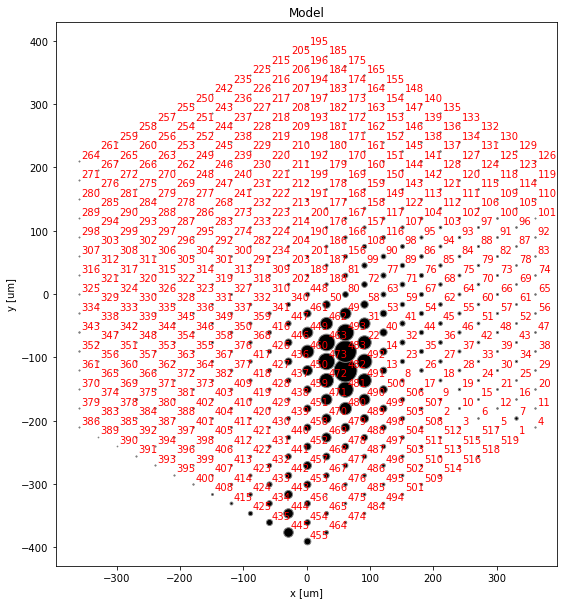

In [50]:
# plot real EI and label electrodes
# plot electrode array using plt
fig = plt.figure(figsize=(10,10))

# side by side subplots

ax = fig.add_subplot(111)
                    
for ii,elec in enumerate(electrodes):

    ax.scatter(elec[0],elec[1],s=0.5, facecolors='grey', edgecolors='grey', marker='o')
    ax.scatter(elec[0],elec[1],s=ei_min_real[ii]*1.2, facecolors='black', edgecolors='grey', marker='o')
    

    

# # ----------------- plot X on selected electrodes -----------------
# electrodes_to_plot = [482,444]

# for elec in electrodes_to_plot:
#     ax.plot(electrodes[elec][0],electrodes[elec][1],'X',color='black',markersize=10)
#     ax2.plot(electrodes[elec][0],electrodes[elec][1],'X',color='black',markersize=10)
# # ----------------- plot X on selected electrodes -----------------

# electrodes_to_plot = [482,444]

# for elec in electrodes_to_plot:
#     ax.text(electrodes[elec][0],electrodes[elec][1],str(elec),fontsize=10)
#     ax2.text(electrodes[elec][0],electrodes[elec][1],str(elec),fontsize=10)

# # ------------ plot electrode numbers -----------
k = 1
for elec in electrodes:
    # Plot electrode number identified by str(k) at electrode locations
    ax.text(elec[0]+5,elec[1]+5,str(k),fontsize=10,c='red')
    k += 1
# # ------------ plot electrode numbers -----------

ax.set_aspect('equal')
ax.set_title('Model')
ax.set_xlabel('x [um]')
ax.set_ylabel('y [um]')
# plt.savefig("figures/figure2_EI.pdf",format="pdf", bbox_inches="tight")
plt.show()

In [51]:
# # plot real EI for an electrode 
# elec = 434
# fig = plt.figure(figsize=(10,10))
# ax = fig.add_subplot(111)
# # ax x-asis is time with units of ms
# t_real = np.arange(0,ei_real.shape[1],1)*.05
# ax.plot(t_real,ei_real[elec,:]*3.6, linewidth=3)
# ax.set_title('Real')
# ax.set_xlabel('Time [ms]')
# plt.savefig("figures/defense_axon2.pdf",format="pdf", bbox_inches="tight")
# plt.show()

## Normal analysis below

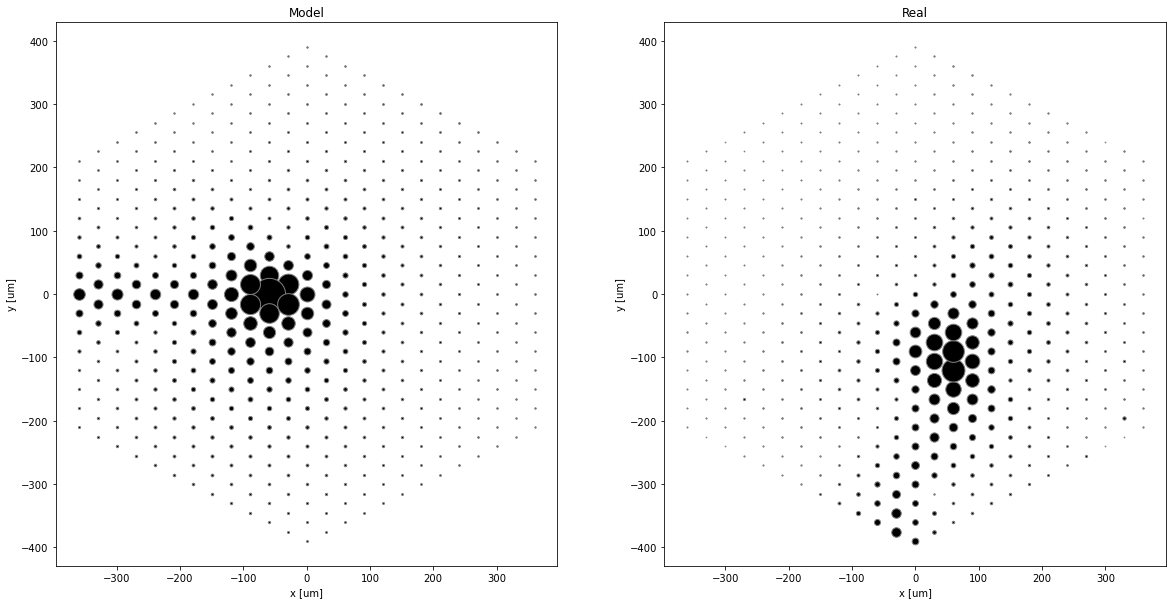

In [52]:
# plot electrode array using plt
fig = plt.figure(figsize=(20,10))

# side by side subplots

ax = fig.add_subplot(121)
ax2 = fig.add_subplot(122)
                    
for ii,elec in enumerate(electrodes):
    # ax.plot(elec[0],elec[1],'o',color='grey',markersize=2,alpha=0.8)
    # ax2.plot(elec[0],elec[1],'o',color='grey',markersize=2,alpha=0.8)

    # ax.plot(elec[0],elec[1],'o',color='grey',markersize=0.5,alpha=0.2)
    # ax.plot(elec[0],elec[1],'o',color='black',markersize=ei_min_sim[ii]*.08)
    # ax2.plot(elec[0],elec[1],'o',color='grey',markersize=0.5,alpha=0.2)
    # ax2.plot(elec[0],elec[1],'o',color='black',markersize=ei_min_real[ii]*.08)


    ax.scatter(elec[0],elec[1],s=0.5, facecolors='grey', edgecolors='grey', marker='o')
    ax.scatter(elec[0],elec[1],s=ei_min_sim[ii]*1.2, facecolors='black', edgecolors='grey', marker='o')
    ax2.scatter(elec[0],elec[1],s=0.5, facecolors='grey', edgecolors='grey', marker='o')
    ax2.scatter(elec[0],elec[1],s=ei_min_real[ii]*1.2, facecolors='black', edgecolors='grey', marker='o')

    

# # ----------------- plot X on selected electrodes -----------------
# electrodes_to_plot = [482,444]

# for elec in electrodes_to_plot:
#     ax.plot(electrodes[elec][0],electrodes[elec][1],'X',color='black',markersize=10)
#     ax2.plot(electrodes[elec][0],electrodes[elec][1],'X',color='black',markersize=10)
# # ----------------- plot X on selected electrodes -----------------

# electrodes_to_plot = [482,444]

# for elec in electrodes_to_plot:
#     ax.text(electrodes[elec][0],electrodes[elec][1],str(elec),fontsize=10)
#     ax2.text(electrodes[elec][0],electrodes[elec][1],str(elec),fontsize=10)

# # ------------ plot electrode numbers -----------
# k = 1
# for elec in electrodes:
#     # Plot electrode number identified by str(k) at electrode locations
#     ax.text(elec[0]+5,elec[1]+5,str(k),fontsize=10)
#     k += 1
# # ------------ plot electrode numbers -----------

ax.set_aspect('equal')
ax2.set_aspect('equal')
ax.set_title('Model')
ax2.set_title('Real')
ax.set_xlabel('x [um]')
ax.set_ylabel('y [um]')
ax2.set_xlabel('x [um]')
ax2.set_ylabel('y [um]')
# plt.savefig("figures/figure2_EI.pdf",format="pdf", bbox_inches="tight")
plt.show()

## Plot extracellular voltage recording and top electrodes 

## Nice e_extra at axon

In [93]:
ei_sim = np.array(ei_sim)

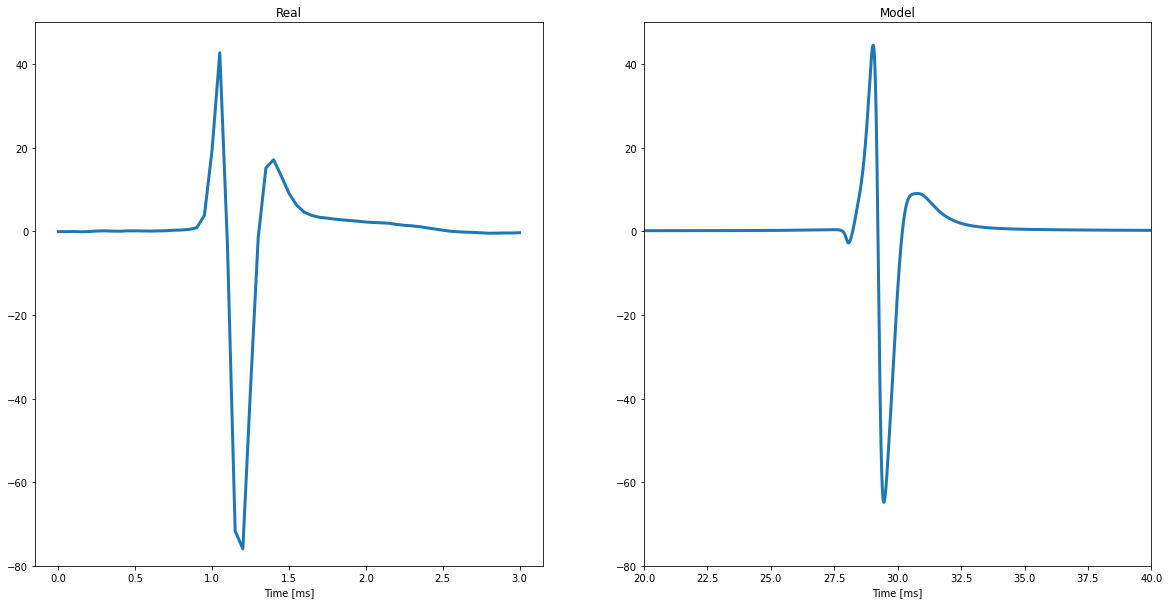

In [94]:
axon_elec = 444
fig = plt.figure(figsize=(20,10))
ax = fig.add_subplot(121)
ax2 = fig.add_subplot(122)
# ax x-asis is time with units of ms
t_real = np.arange(0,ei_real.shape[1],1)*.05
t_sim = np.arange(0,ei_sim.shape[1],1)*.005
ax.plot(t_real,ei_real[axon_elec,:]*3.6, linewidth=3)
ax2.plot(t_sim,ei_sim[axon_elec,:], linewidth=3)
ax.set_title('Real')
ax2.set_title('Model')
ax.set_xlabel('Time [ms]')
ax2.set_xlabel('Time [ms]')
ax2.set_xlim(20,40)
ax2.set_ylim(-80,50)
ax.set_ylim(-80,50)
plt.savefig("figures/figure2_B_axon.pdf",format="pdf", bbox_inches="tight")
plt.show()

## Nice e_extra at soma

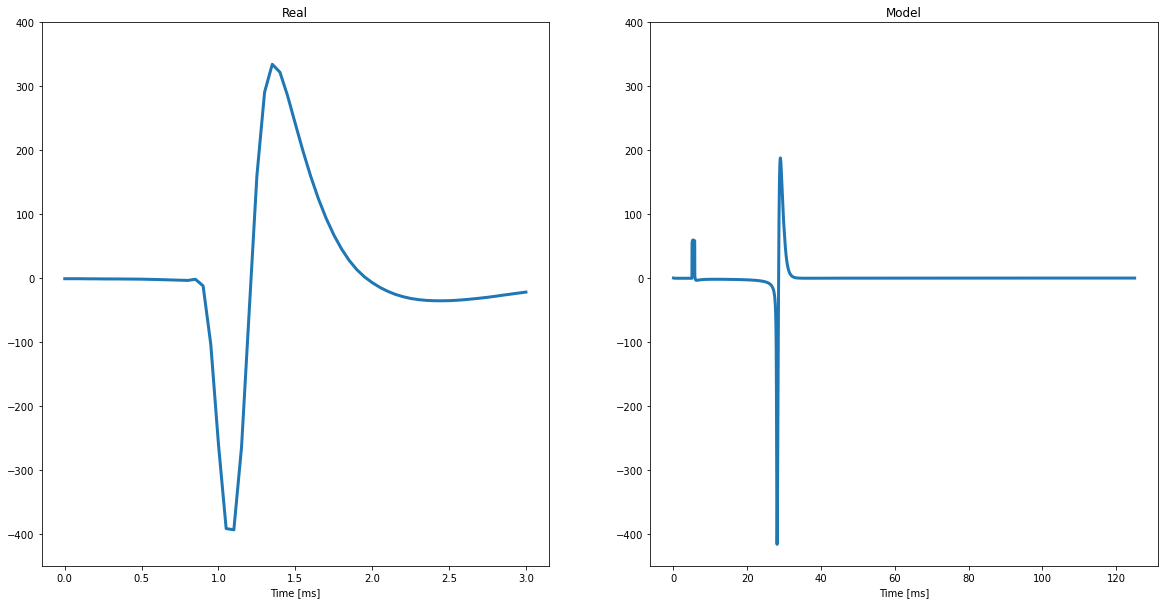

In [95]:
axon_elec = 483-1
fig = plt.figure(figsize=(20,10))
ax = fig.add_subplot(121)
ax2 = fig.add_subplot(122)
# ax x-asis is time with units of ms
t_real = np.arange(0,ei_real.shape[1],1)*.05
t_sim = np.arange(0,ei_sim.shape[1],1)*.005
ax.plot(t_real,ei_real[axon_elec,:]*3.6, linewidth=3)
ax2.plot(t_sim,ei_sim[axon_elec,:], linewidth=3)
ax.set_title('Real')
ax2.set_title('Model')
ax.set_xlabel('Time [ms]')
ax2.set_xlabel('Time [ms]')
# ax2.set_xlim(3,21)
ax2.set_ylim(-450,400)
ax.set_ylim(-450,400)
plt.savefig("figures/figure2_B_soma.pdf",format="pdf", bbox_inches="tight")
plt.show()

In [96]:
electrodes[482]

array([ 60., -90.])

4.0 28.875
shift 24.875


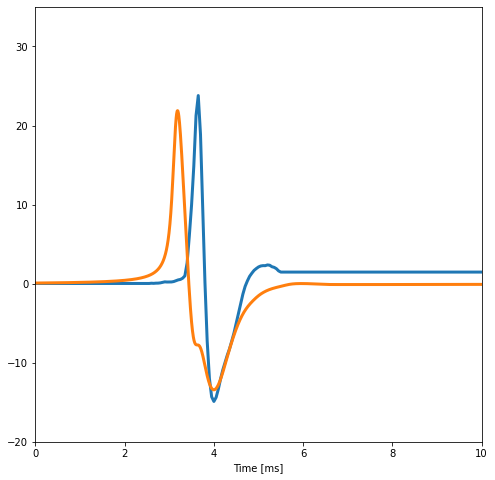

In [97]:
# Pick out the exact traces of interest 
# elec = 98 
# elec = 432
# elec = 490
# elec = 482
# elec = 471
# elec = 444
elec = 107 # 99
ei_real_plot = ei_real[elec,:]*3.6
ei_sim_plot = ei_sim[elec,:]

# Pad ei_real_plot in the front by 100 samples
ei_real_plot = np.pad(ei_real_plot, (50,100), 'constant', \
                      constant_values=(ei_real_plot[0], ei_real_plot[-1]))

# Make time vectors
t_real = np.arange(0,ei_real_plot.shape[0],1)*.05
t_sim = np.arange(0,ei_sim_plot.shape[0],1)*.005

# Align peak and plot on the same plot 

# find peak of real and model data
peak_real = np.argmin(ei_real_plot)
peak_sim = np.argmin(ei_sim_plot)

print(t_real[peak_real], t_sim[peak_sim])

# Shift model data to align with real data, account for different time scales
shift = t_sim[peak_sim] - t_real[peak_real]
print('shift', shift)
t_sim_shift = t_sim - shift

fig = plt.figure(figsize=(8,8))
ax = fig.add_subplot(111)

# ax x-asis is time with units of ms
ax.plot(t_real,ei_real_plot, linewidth=3, label='data')
ax.plot(t_sim_shift,ei_sim_plot, linewidth=3, label='model')
ax.set_xlabel('Time [ms]')
ax.set_ylim(-20,35)
ax.set_xlim(0,10)
plt.savefig("figures/figure2_rec_dend.pdf",format="pdf", bbox_inches="tight")
plt.show()


In [98]:
# Calculate peak width on ei_sim_plot
# 1. find peak
peak_sim = np.argmin(ei_sim_plot)
# 2. find half max
half_max = ei_sim_plot[peak_sim]/2
# 3. find left and right half max
left_half_max = np.argmin(np.abs(ei_sim_plot[:peak_sim]-half_max))
right_half_max = np.argmin(np.abs(ei_sim_plot[peak_sim:]-half_max))+peak_sim
# 4. calculate width
width = t_sim_shift[right_half_max]-t_sim_shift[left_half_max]
print('sim width', width)

# Calculate peak width on ei_sim_plot
# 1. find peak
peak_real = np.argmin(ei_real_plot)
# 2. find half max
half_max = ei_real_plot[peak_real]/2
# 3. find left and right half max
left_half_max = np.argmin(np.abs(ei_real_plot[:peak_real]-half_max))
right_half_max = np.argmin(np.abs(ei_real_plot[peak_real:]-half_max))+peak_real
# 4. calculate width
width = t_real[right_half_max]-t_real[left_half_max]
print('real width', width)

sim width 0.9000000000000021
real width 0.5500000000000003


In [32]:
top_100_elecs = np.argsort(ei_min_real)[::-1][:100]
print(top_100_elecs)


[481 482 462 492 472 480 491 471 490  21 459 479 461  30  48 470 489 448
 449 443 444 468 469 478 488 442 456 499  49  57 458  39 460  13 450 445
 435 452 451 467 457 498 454  12  52 441 477 487 434 455 453  79 433  71
 440 497 466 446  98 432  76  40  31 436  62  70 476  89  80  58 486  88
 447 505 504  43 439 496  53  22 431 424 107 425  34  66  75 155 426 339
 415 438  97 464 115  35  85  44 463  61]


In [33]:
t_sim = np.arange(0,ei_sim.shape[1],1)*.005
print(t_sim)

[0.00000e+00 5.00000e-03 1.00000e-02 ... 1.24990e+02 1.24995e+02
 1.25000e+02]


Electrode:  481


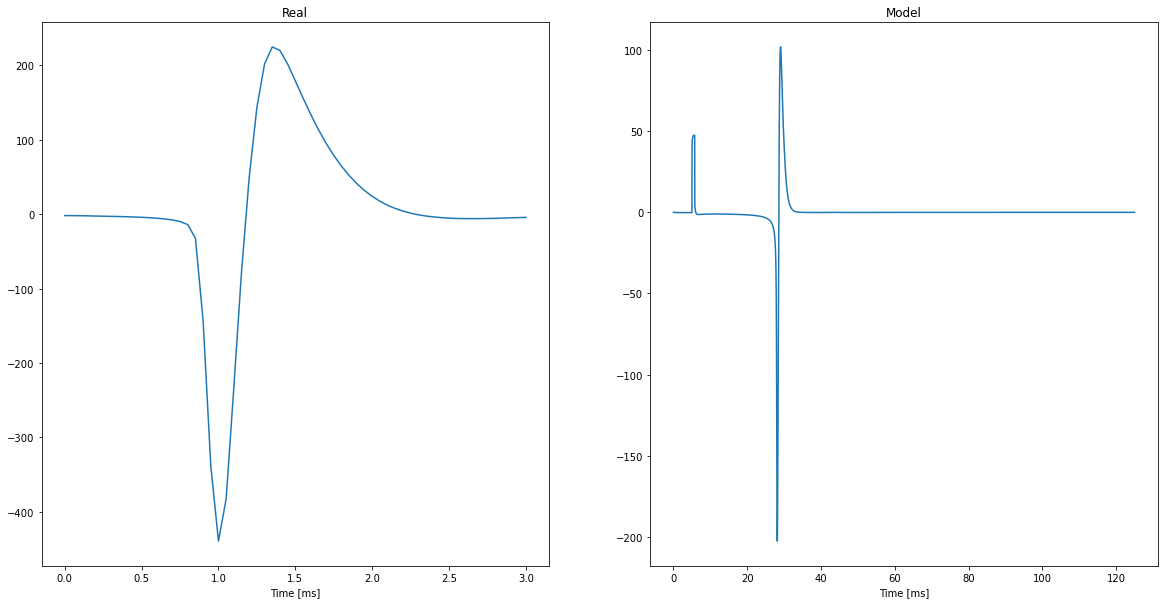

Electrode:  482


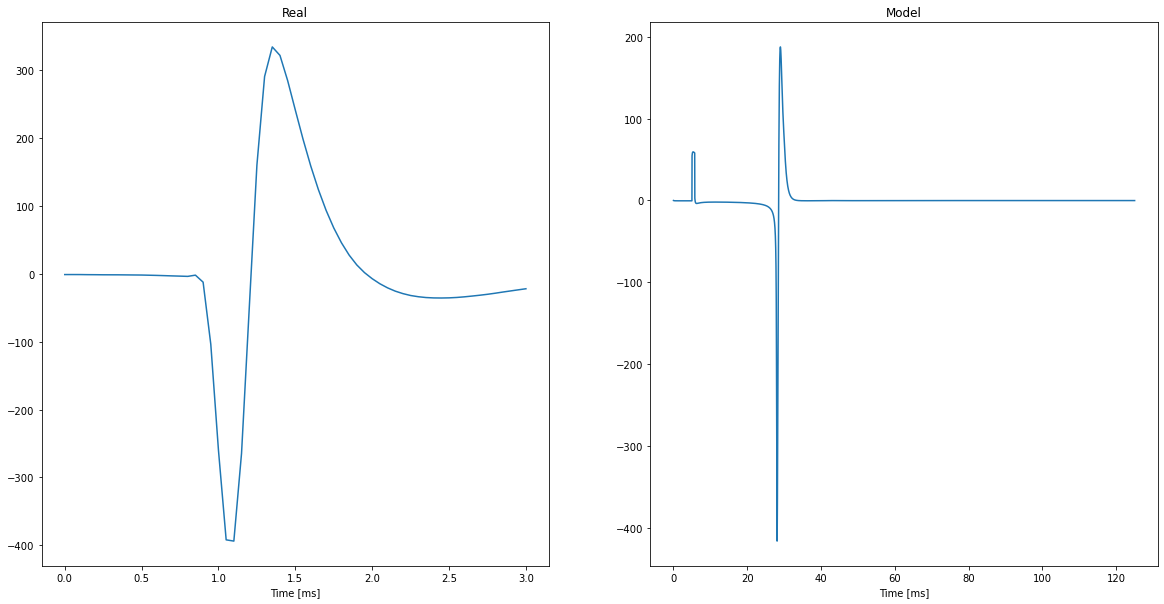

Electrode:  462


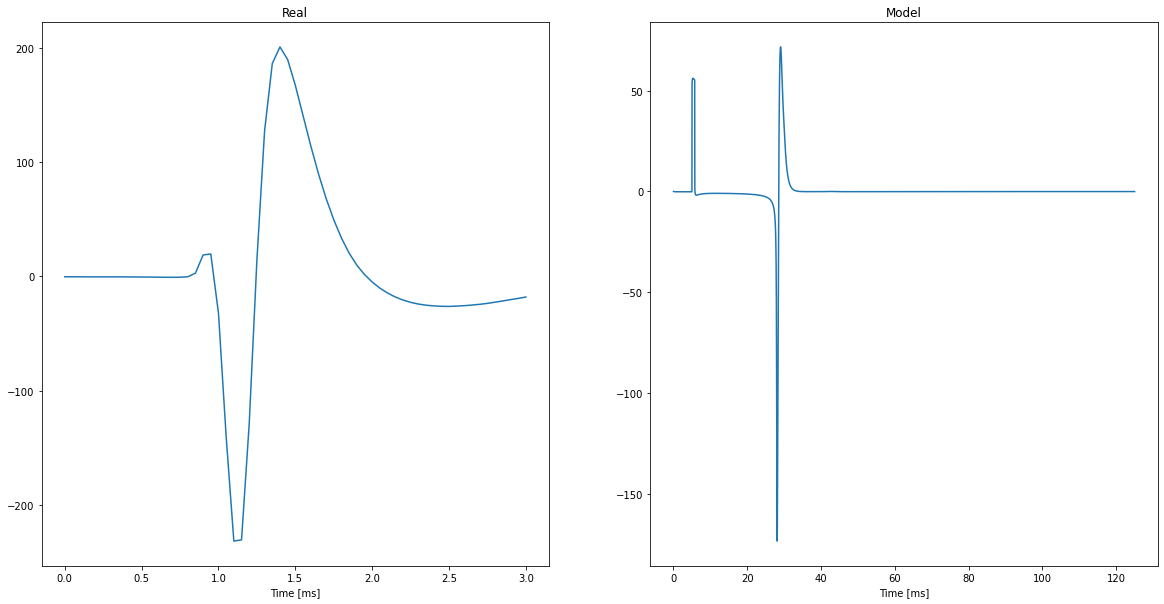

Electrode:  492


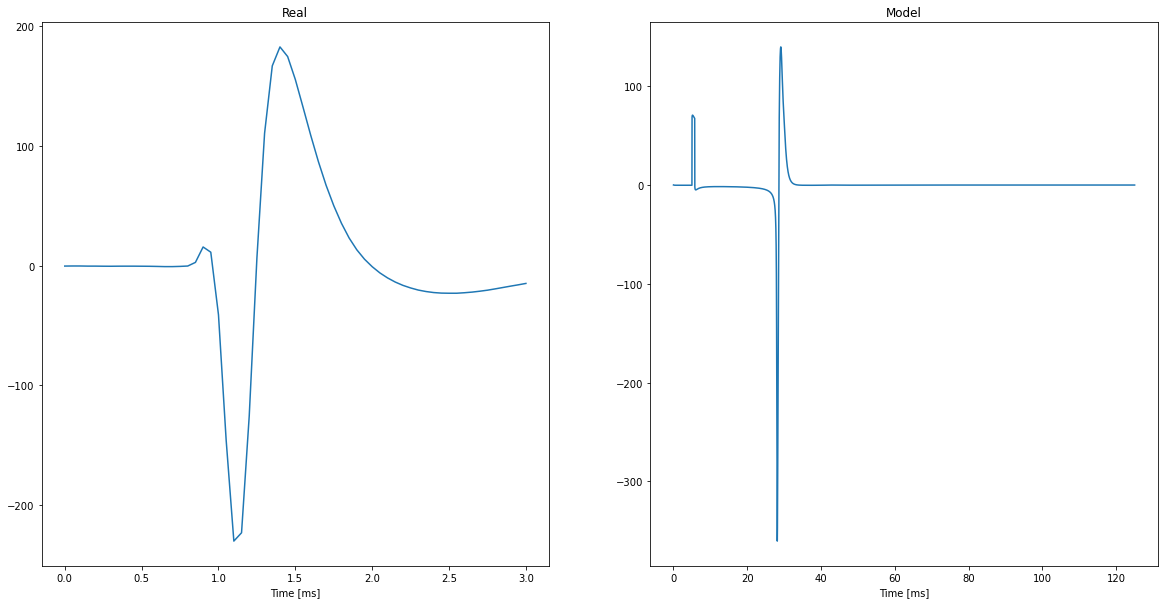

Electrode:  472


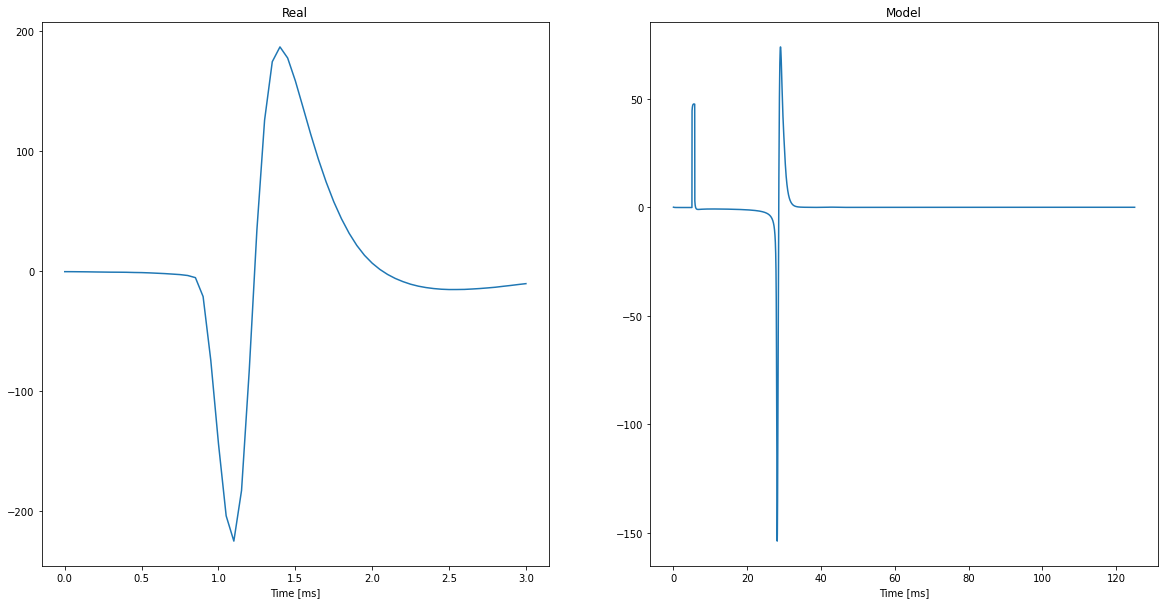

Electrode:  480


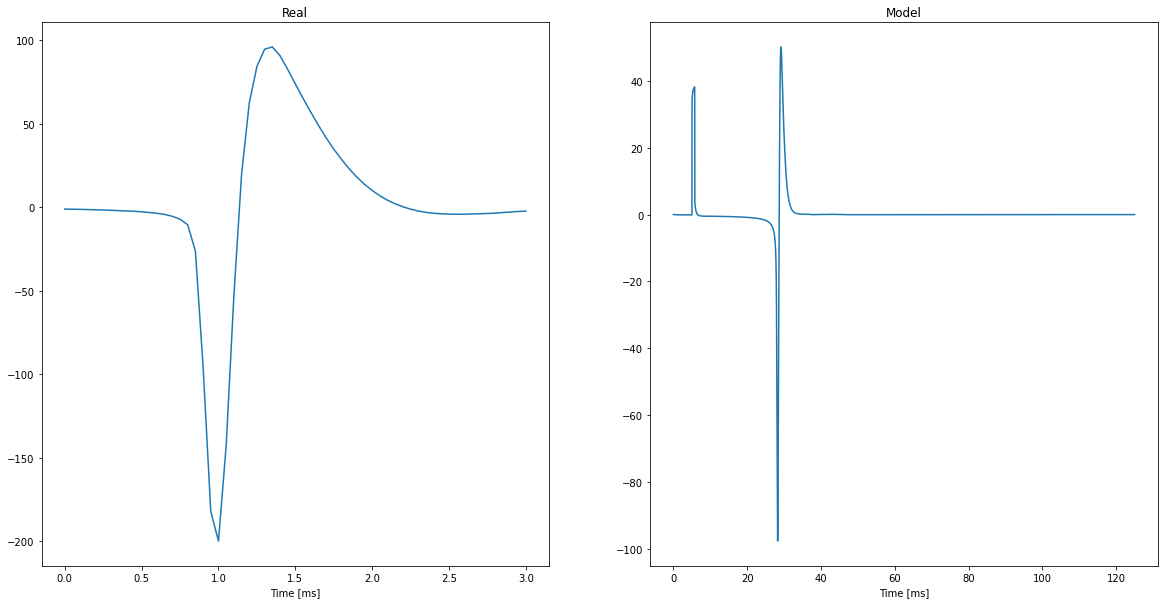

Electrode:  491


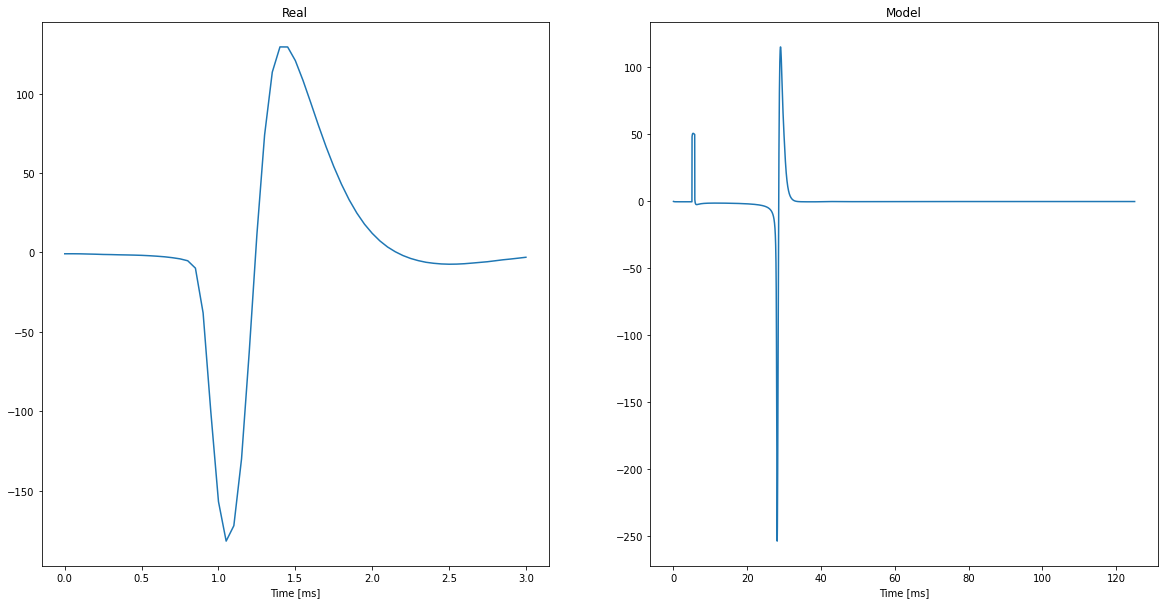

Electrode:  471


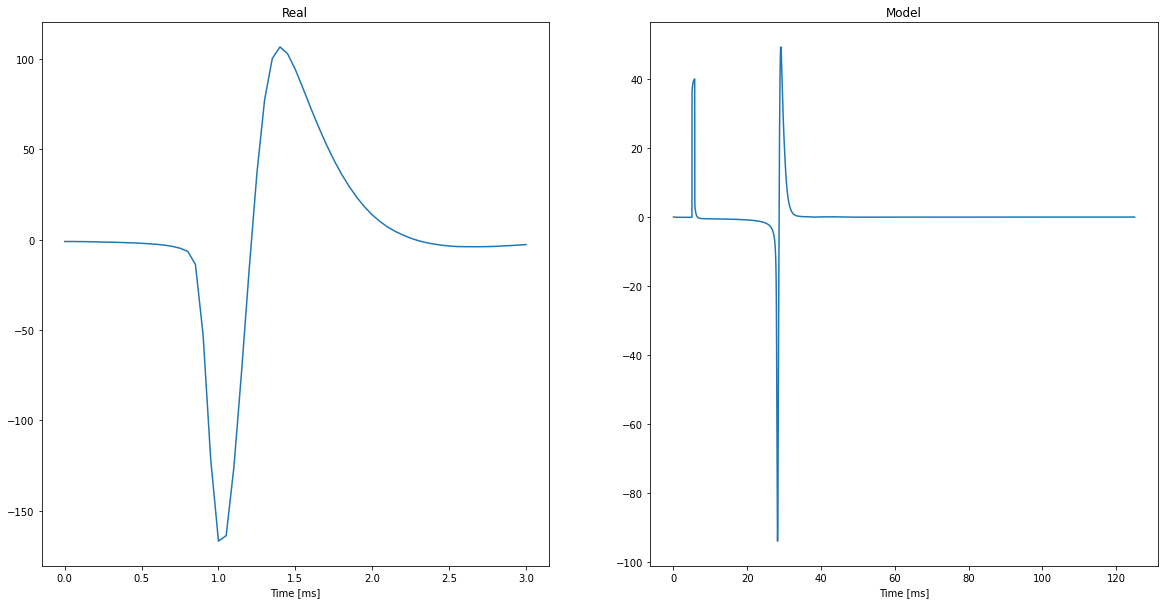

Electrode:  490


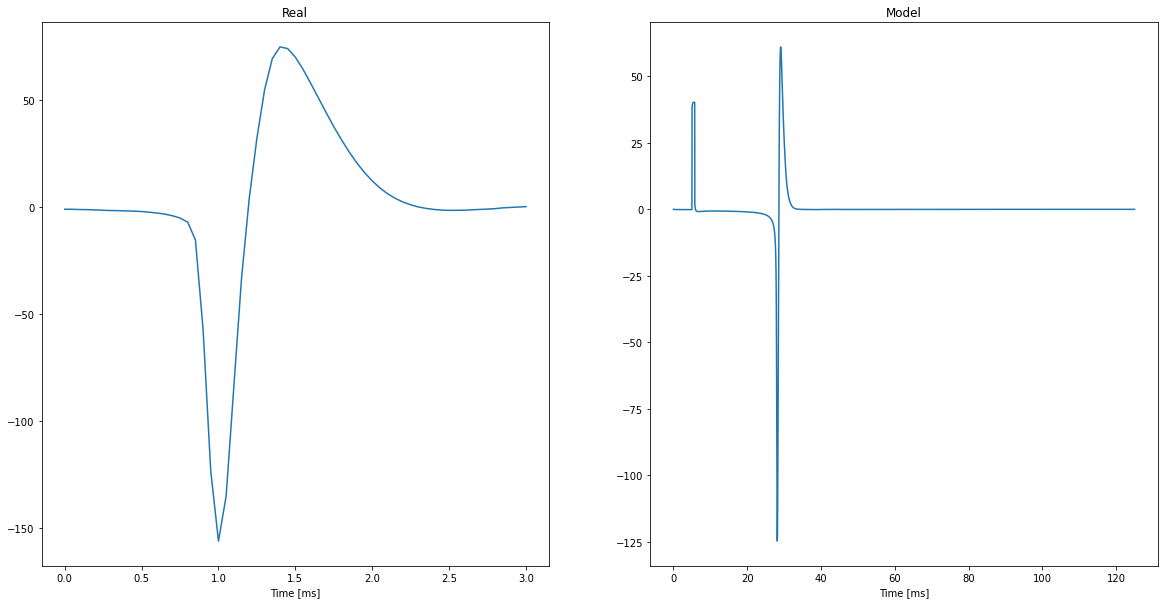

Electrode:  21


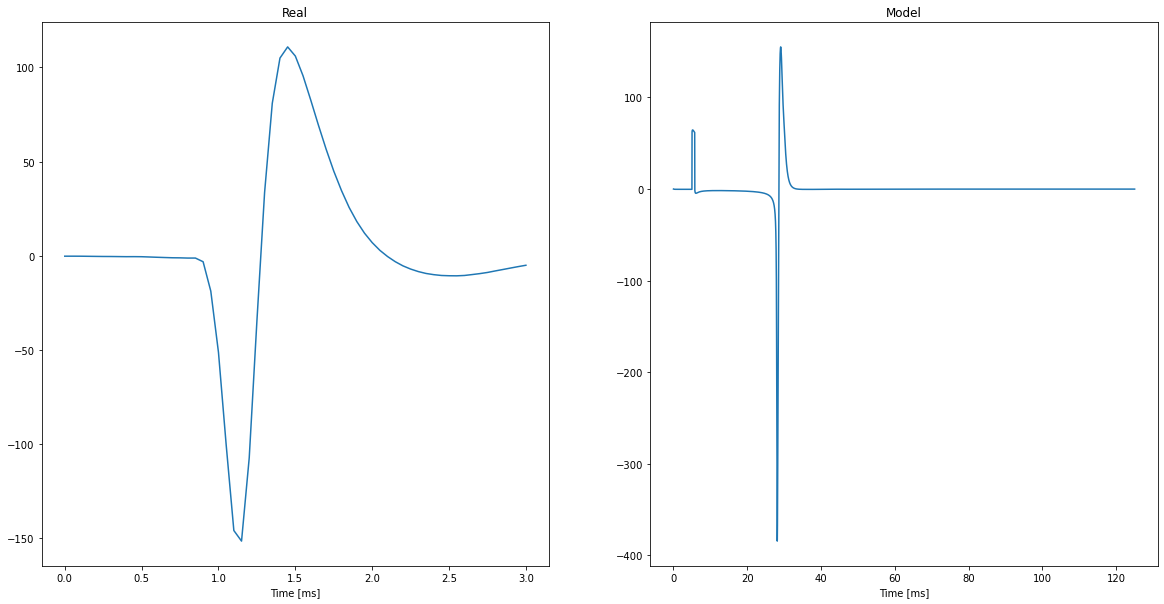

In [34]:
ei_sim = np.array(ei_sim)

for i in range(10):
    print('Electrode: ', top_100_elecs[i])
    # plot EI 
    fig = plt.figure(figsize=(20,10))
    ax = fig.add_subplot(121)
    ax2 = fig.add_subplot(122)
    # ax x-asis is time with units of ms
    t_real = np.arange(0,ei_real.shape[1],1)*.05
    t_sim = np.arange(0,ei_sim.shape[1],1)*.005
    ax.plot(t_real,ei_real[top_100_elecs[i],:]*3.6)
    ax2.plot(t_sim,ei_sim[top_100_elecs[i],:])
    ax.set_title('Real')
    ax2.set_title('Model')
    ax.set_xlabel('Time [ms]')
    ax2.set_xlabel('Time [ms]')
    # ax2.set_xlim(14,19)
    plt.show()
    


## Same extracellular voltage recordings as above, but now for axonal

In [37]:
# Find where np.min(ei_sim) is between 30 and 60 and likewise for np.min(ei_real)
axonal_elecs = np.where((ei_min_real > 20) & (ei_min_real < 40))[0]
print(axonal_elecs)

[ 12  31  40  52  62  71  76  79  98 432 433 434 436 440 441 446 453 454
 455 466 477 487 497]


Electrode:  12


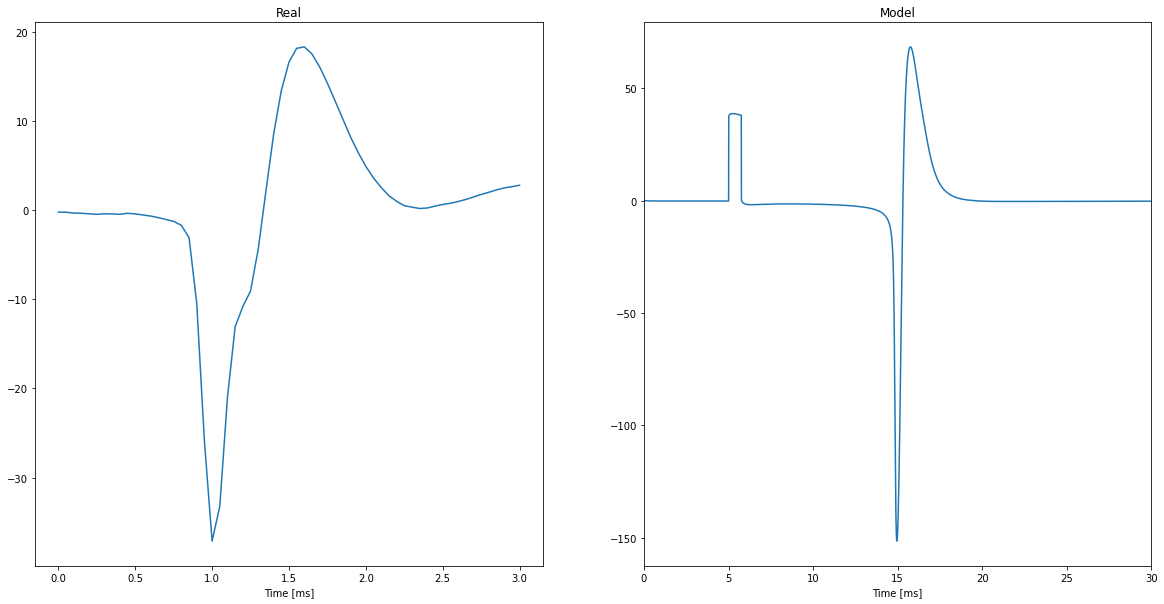

Electrode:  31


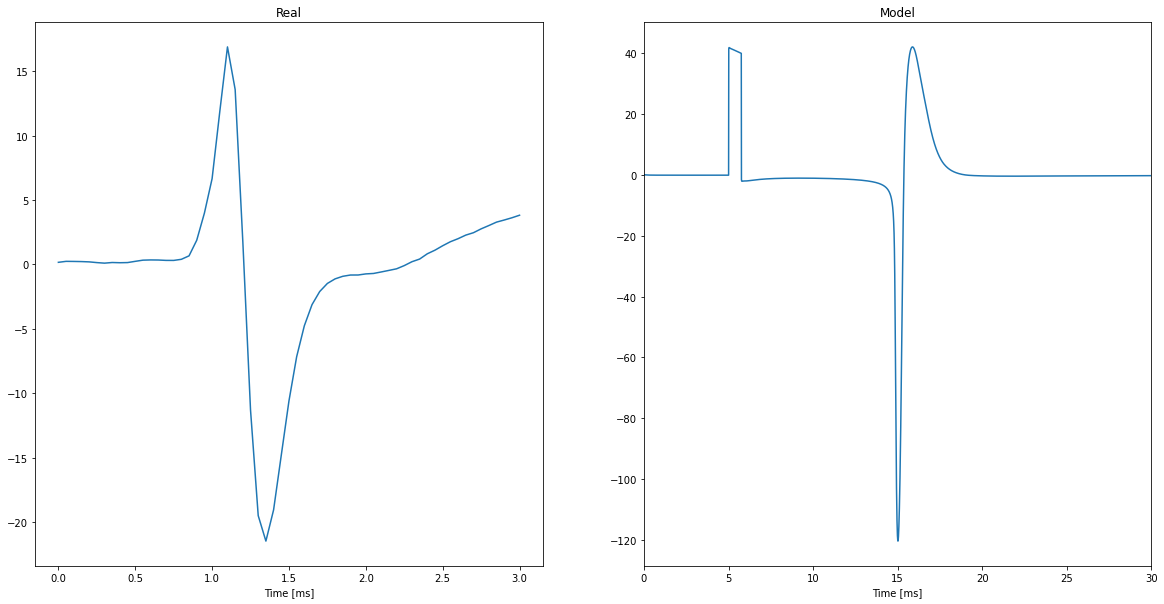

Electrode:  40


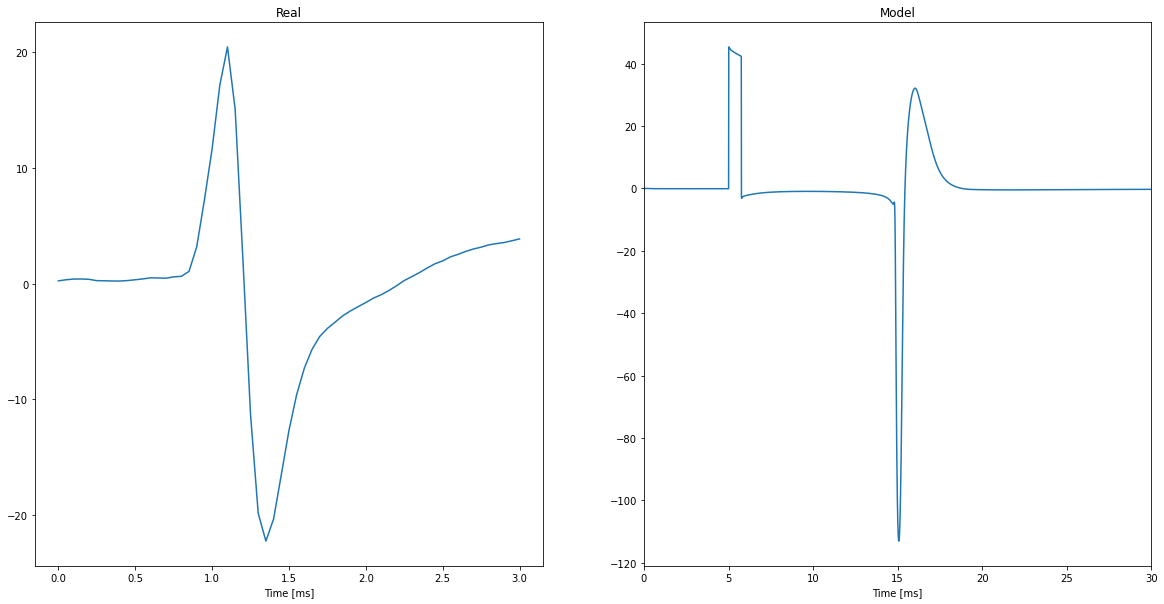

Electrode:  52


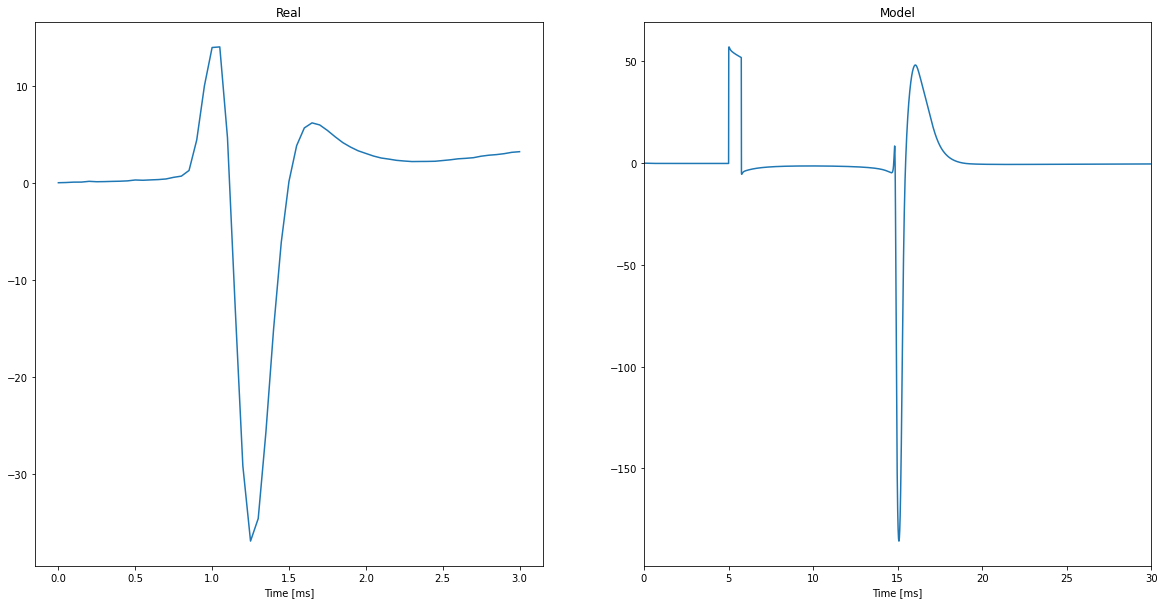

Electrode:  62


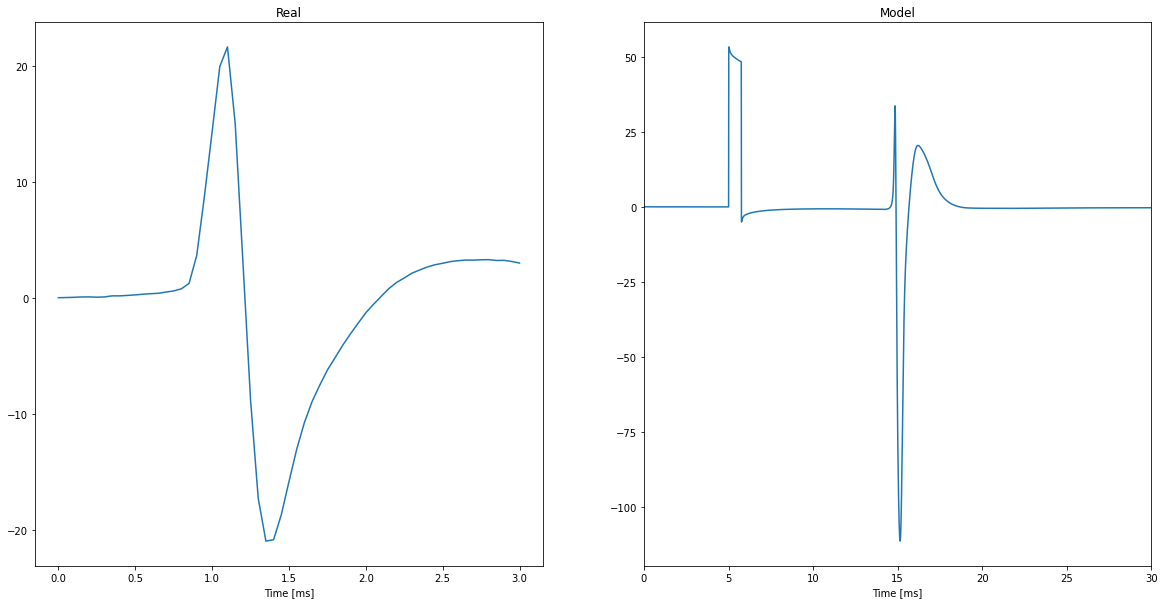

Electrode:  71


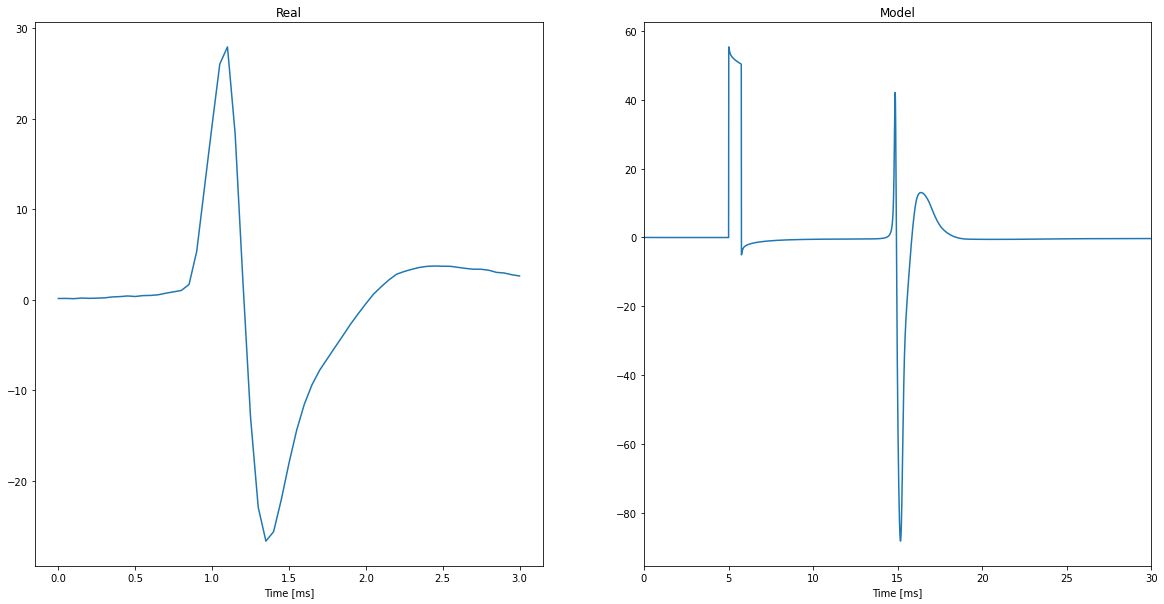

Electrode:  76


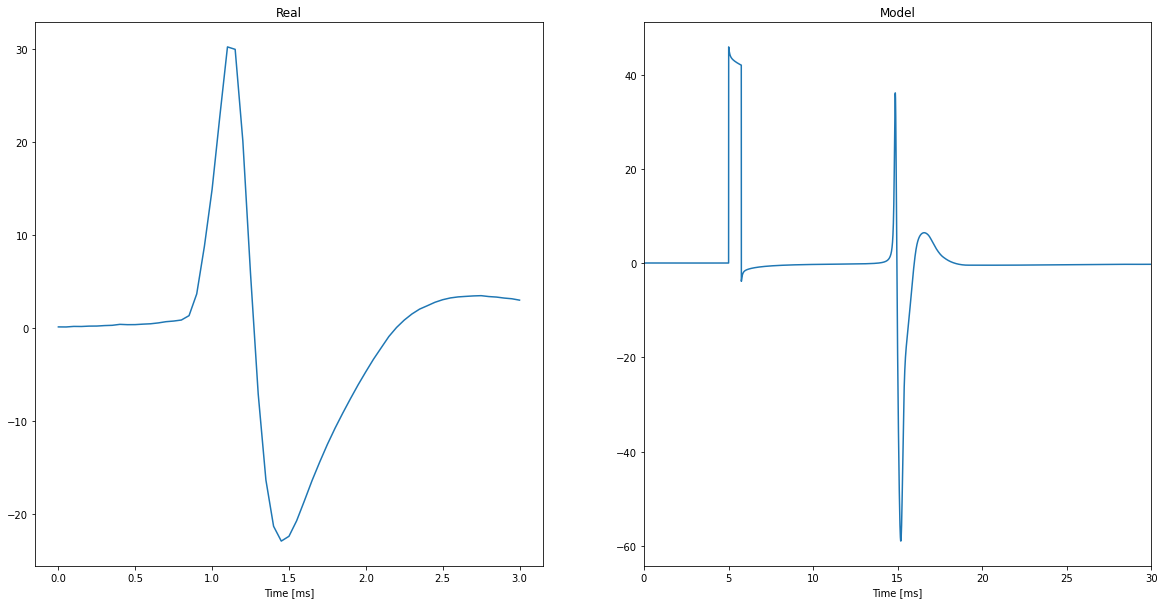

Electrode:  79


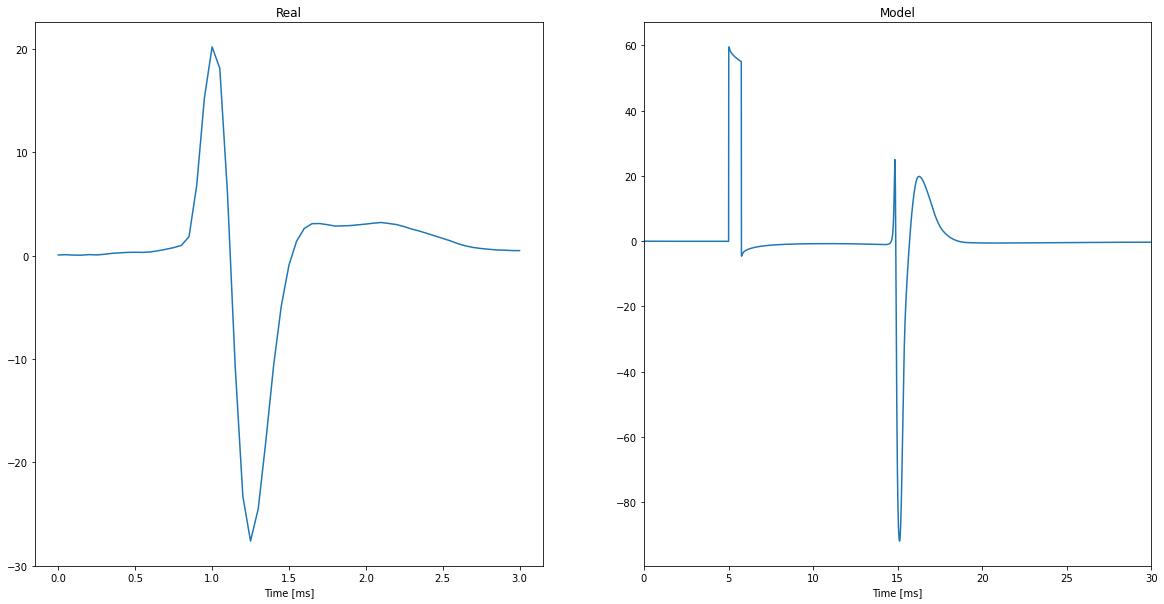

Electrode:  98


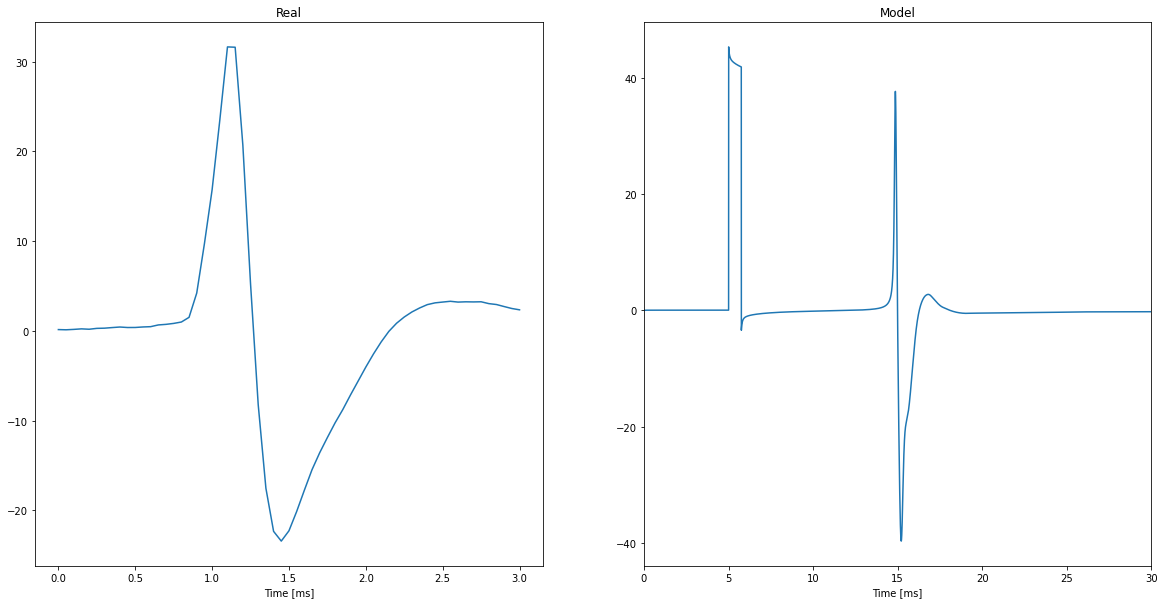

Electrode:  432


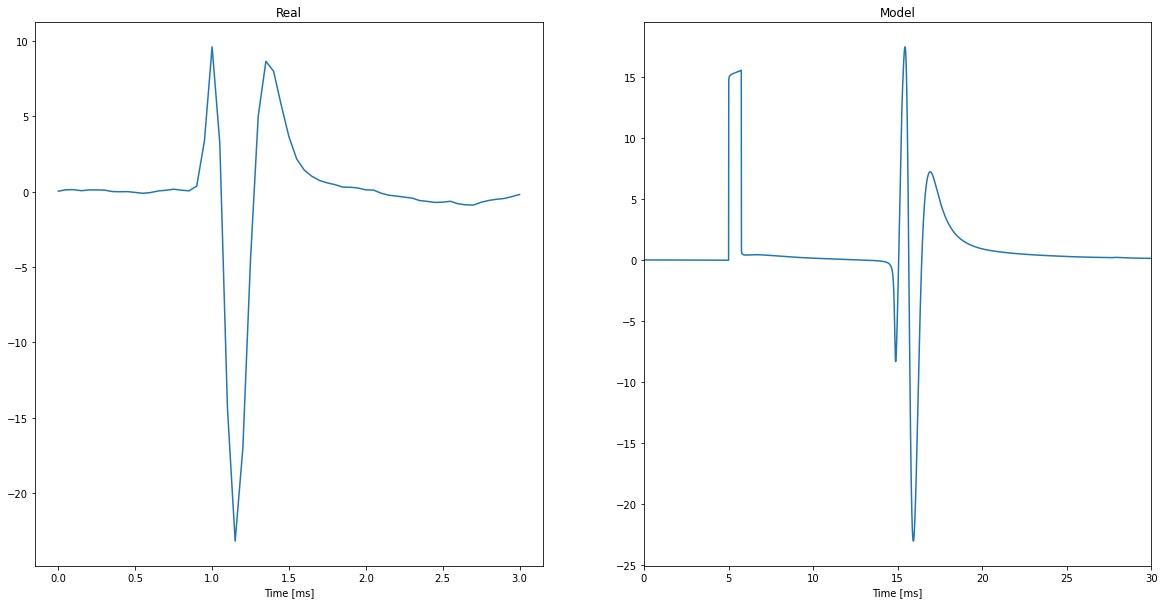

In [38]:
ei_sim = np.array(ei_sim)

for i in range(10):
    print('Electrode: ', axonal_elecs[i])
    # plot EI 
    fig = plt.figure(figsize=(20,10))
    ax = fig.add_subplot(121)
    ax2 = fig.add_subplot(122)
    # ax x-asis is time with units of ms
    t_real = np.arange(0,ei_real.shape[1],1)*.05
    t_sim = np.arange(0,ei_sim.shape[1],1)*.005
    ax.plot(t_real,ei_real[axonal_elecs[i],:]*3.6)
    ax2.plot(t_sim,ei_sim[axonal_elecs[i],:])
    ax.set_title('Real')
    ax2.set_title('Model')
    ax.set_xlabel('Time [ms]')
    ax2.set_xlabel('Time [ms]')
    ax2.set_xlim(0,30)
    plt.show()

## Figure out what real cell to mirror

In [26]:
datapath = '/Volumes/Analysis/2020-10-06-7/kilosort_data000/data000'
datarun = 'data000'
vcd = vl.load_vision_data(datapath,datarun,
                          include_neurons=True,
                          include_ei=True,
                          include_params=True,
                          include_noise=True)

# look at only sorted parasol cells
cellids = vcd.get_all_cells_similar_to_type('parasol')

In [27]:
print(cellids)

[336, 504, 507, 509, 351, 220, 535, 242, 244, 395, 78, 81, 399, 84, 608, 259, 419, 621, 623, 626, 426, 275, 282, 283, 439, 442, 166, 444, 171, 447, 292, 296, 301, 302, 458, 311, 487, 490]


In [28]:
high_snr_cells = []
for cell in cellids:
    # Extract EI and specifically max EI value
    ei_real = vcd.get_ei_for_cell(cell).ei
    ei_min_real = -1*np.min(ei_real,axis=1)
    
    if np.max(ei_min_real) > (200/3.6) and np.max(ei_min_real) < 300:
        print('High signal cell: ', cell)
        high_snr_cells.append(cell)
        


High signal cell:  504
High signal cell:  509
High signal cell:  351
High signal cell:  535
High signal cell:  244
High signal cell:  78
High signal cell:  81
High signal cell:  84
High signal cell:  259
High signal cell:  621
High signal cell:  623
High signal cell:  426
High signal cell:  283
High signal cell:  439
High signal cell:  442
High signal cell:  447
High signal cell:  458
High signal cell:  311
High signal cell:  490


Max EI:  259.71002
Cell:  504


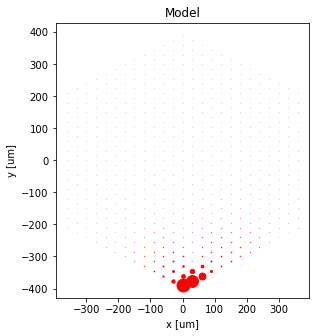

Max EI:  524.32556
Cell:  509


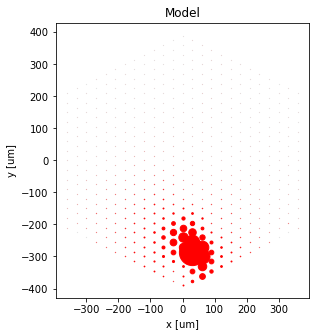

Max EI:  228.98381
Cell:  351


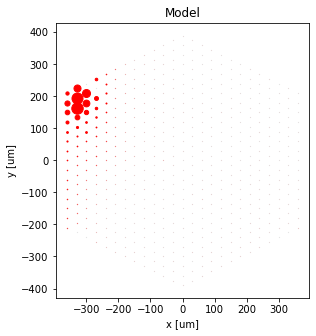

Max EI:  439.59503
Cell:  535


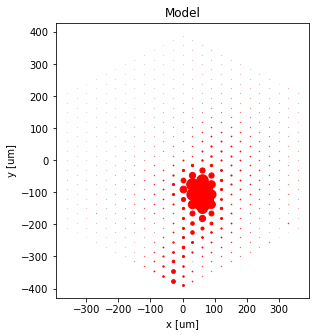

Max EI:  250.10521
Cell:  244


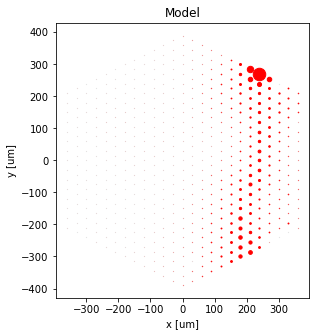

Max EI:  221.58372
Cell:  78


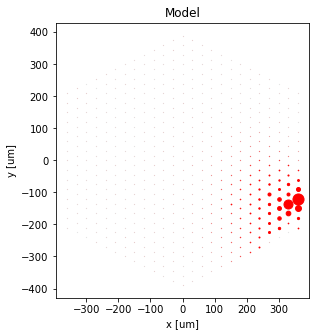

Max EI:  236.94301
Cell:  81


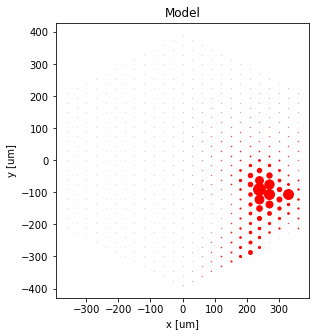

Max EI:  234.95567
Cell:  84


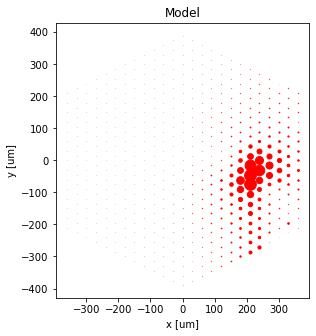

Max EI:  254.50455
Cell:  259


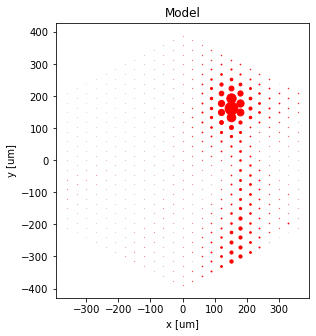

Max EI:  203.6841
Cell:  621


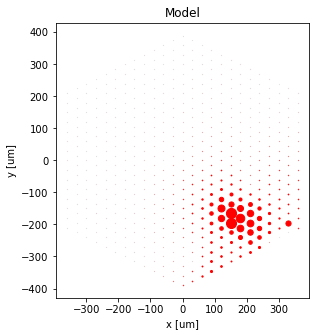

Max EI:  237.51845
Cell:  623


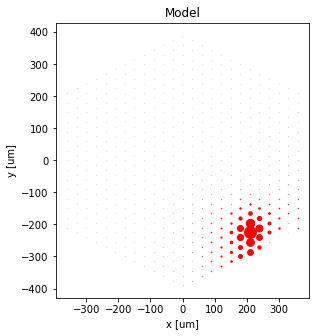

Max EI:  228.66553
Cell:  426


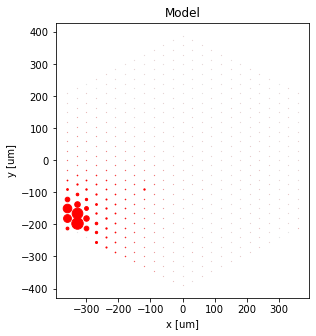

Max EI:  222.85493
Cell:  283


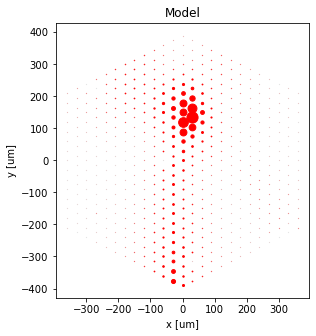

Max EI:  239.1105
Cell:  439


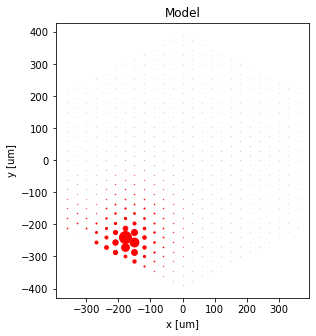

Max EI:  232.41228
Cell:  442


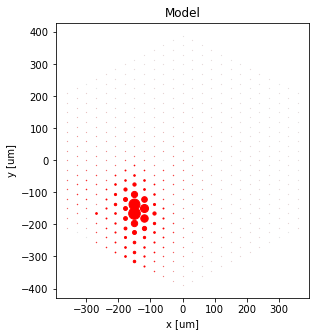

Max EI:  325.6969
Cell:  447


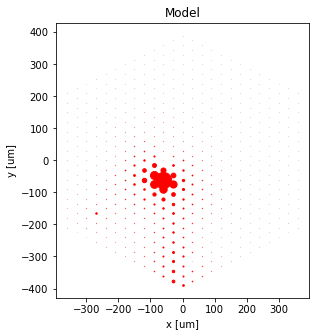

Max EI:  294.9688
Cell:  458


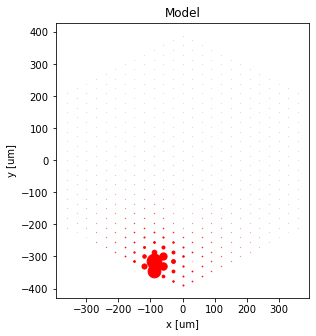

Max EI:  262.80444
Cell:  311


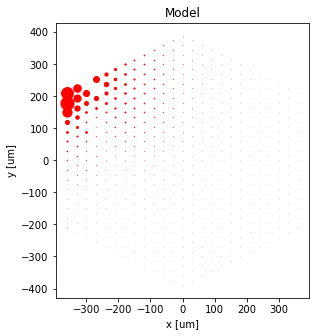

Max EI:  251.46977
Cell:  490


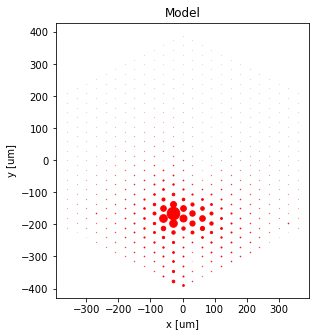

In [30]:
for cell in high_snr_cells:
    # Extract EI and specifically max EI value
    ei_real = vcd.get_ei_for_cell(cell).ei
    ei_min_real = -3.6*np.min(ei_real,axis=1)
    # collapse ei into just minimum for every row, call it ei_min
    
    print('Max EI: ', np.max(ei_min_real))
    print('Cell: ', cell)

    # plot electrode array using plt
    fig = plt.figure(figsize=(10,10))

    # side by side subplots

    ax = fig.add_subplot(121)

    for ii,elec in enumerate(electrodes):
        ax.plot(elec[0],elec[1],'o',color='black',markersize=0.2,alpha=0.2)
        ax.plot(elec[0],elec[1],'o',color='red',markersize=ei_min_real[ii]*.05)

    ax.set_aspect('equal')
    ax.set_title('Model')
    ax.set_xlabel('x [um]')
    ax.set_ylabel('y [um]')
    
    plt.show()
